# 01. Construcció del dataset final

Aquest notebook construeix el dataset final del projecte a partir de dades climàtiques mensuals i índexs de teleconnexió atmosfèrica.

Objectius:

1. Carregar o descarregar les dades climàtiques ERA5 i ERA5-Land.
2. Carregar els índexs NAO, WeMO i ENSO/RONI.
3. Definir subregions geogràfiques
4. Agregar les variables climàtiques per subregió i mes.
5. Crear anomalies mensuals respecte a la climatologia de cada subregió i mes.
6. Exportar el dataset final.

In [1]:
%pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 15.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 16.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [cartopy]m3/4 [cartopy]
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import xarray as xr

# Opcional: només necessari si vols descarregar dades de Copernicus des del notebook
try:
    import cdsapi
    CDSAPI_AVAILABLE = True
except ImportError:
    CDSAPI_AVAILABLE = False

BASE = Path("..") if Path("../data_raw").exists() else Path(".")
RAW = BASE / "data_raw"
PROC = BASE / "data_processed"
FIG = BASE / "figures"

for path in [RAW, PROC, FIG]:
    path.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE.resolve())
print("RAW:", RAW.resolve())
print("PROC:", PROC.resolve())
print("FIG:", FIG.resolve())

BASE: /workspace
RAW: /workspace/data_raw
PROC: /workspace/data_processed
FIG: /workspace/figures


In [3]:
ANY_INICI = 1981
ANY_FINAL = 2020

DATA_INICI = f"{ANY_INICI}-01-01"
DATA_FINAL = f"{ANY_FINAL}-12-01"

# Fitxers climàtics principals
ERA5_PATH = RAW / "era5" / "era5_monthly_core_1981_2024.nc"
ERA5_LAND_PATH = RAW / "era5_land" / "era5_land_monthly_1981_2024.nc"

# Carpetes d'extracció si Copernicus retorna ZIP encara que l'extensió sigui .nc
ERA5_EXTRACT_DIR = RAW / "era5" / "era5_monthly_core_1981_2024"
ERA5_LAND_EXTRACT_DIR = RAW / "era5_land" / "era5_land_monthly_1981_2024"

# Fitxers d'índexs
ONI_PATH = RAW / "noaa" / "oni_raw.csv"
RONI_PATH = RAW / "noaa" / "roni_raw.csv"
NAO_PATH = RAW / "noaa" / "nao_raw.csv"
WEMO_PATH = RAW / "teleconnections" / "wemo_raw.txt"

# Sortides
OUT_TELE = PROC / "teleconnections_monthly_1981_2020_v2.csv"
OUT_FULL = PROC / "teleconnections_catalonia_1981_2020_v2.csv"
OUT_MAIN = PROC / "teleconnections_catalonia_1981_2020_main_v2.csv"

In [ ]:
# Aquesta cel·la només s'ha d'executar si encara no tens els fitxers NetCDF a data_raw.
# Si ja els tens, pots saltar-la.

if CDSAPI_AVAILABLE:
    client = cdsapi.Client()

    if not ERA5_PATH.exists():
        print("Descarregant ERA5...")
        ERA5_PATH.parent.mkdir(parents=True, exist_ok=True)

        client.retrieve(
            "reanalysis-era5-single-levels-monthly-means",
            {
                "product_type": "monthly_averaged_reanalysis",
                "variable": [
                    "2m_temperature",
                    "total_precipitation",
                    "mean_sea_level_pressure",
                    "10m_u_component_of_wind",
                    "10m_v_component_of_wind",
                    "sea_surface_temperature",
                ],
                "year": [str(y) for y in range(ANY_INICI, 2025)],
                "month": [f"{m:02d}" for m in range(1, 13)],
                "time": "00:00",
                "format": "netcdf",
                "area": [46, -6, 30, 20],  # nord, oest, sud, est
            },
            str(ERA5_PATH),
        )
    else:
        print("ERA5 ja existeix:", ERA5_PATH)

    if not ERA5_LAND_PATH.exists():
        print("Descarregant ERA5-Land...")
        ERA5_LAND_PATH.parent.mkdir(parents=True, exist_ok=True)

        client.retrieve(
            "reanalysis-era5-land-monthly-means",
            {
                "product_type": "monthly_averaged_reanalysis",
                "variable": [
                    "volumetric_soil_water_layer_1",
                    "volumetric_soil_water_layer_2",
                    "potential_evaporation",
                ],
                "year": [str(y) for y in range(ANY_INICI, 2025)],
                "month": [f"{m:02d}" for m in range(1, 13)],
                "time": "00:00",
                "format": "netcdf",
                "area": [46, -6, 30, 20],
            },
            str(ERA5_LAND_PATH),
        )
    else:
        print("ERA5-Land ja existeix:", ERA5_LAND_PATH)

else:
    print("cdsapi no està instal·lat. Si ja tens els fitxers a data_raw, pots continuar.")

In [4]:
def extract_if_zip(path: Path, extract_dir: Path) -> list[Path]:
    """
    Copernicus pot retornar un ZIP encara que l'extensió sigui .nc.
    Aquesta funció comprova si el fitxer és ZIP i, si cal, l'extreu.
    Retorna la llista de fitxers NetCDF disponibles.
    """
    extract_dir.mkdir(parents=True, exist_ok=True)

    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path, "r") as z:
            z.extractall(extract_dir)
        files = sorted(extract_dir.glob("*.nc"))
    else:
        files = [path]

    if not files:
        raise FileNotFoundError(f"No s'han trobat fitxers NetCDF a {extract_dir}")

    return files


era5_files = extract_if_zip(ERA5_PATH, ERA5_EXTRACT_DIR)
land_files = extract_if_zip(ERA5_LAND_PATH, ERA5_LAND_EXTRACT_DIR)

print("ERA5 files:", era5_files)
print("ERA5-Land files:", land_files)

ERA5 files: [PosixPath('../data_raw/era5/era5_monthly_core_1981_2024/data_stream-moda_stepType-avgad.nc'), PosixPath('../data_raw/era5/era5_monthly_core_1981_2024/data_stream-moda_stepType-avgua.nc')]
ERA5-Land files: [PosixPath('../data_raw/era5_land/era5_land_monthly_1981_2024/data_stream-moda.nc')]


In [5]:
def open_and_normalize_time(path: Path) -> xr.Dataset:
    """
    Obre un dataset NetCDF i normalitza la coordenada temporal a 'time'.
    """
    ds = xr.open_dataset(path, engine="netcdf4")

    if "valid_time" in ds.coords:
        ds = ds.rename({"valid_time": "time"})

    # Passem cada data al primer dia del mes per evitar problemes d'hores diferents.
    ds["time"] = pd.to_datetime(ds["time"].values).to_period("M").to_timestamp()

    return ds


# ERA5 pot venir separat en dos fitxers: un amb precipitació i un amb la resta de variables.
era5_parts = [open_and_normalize_time(p) for p in era5_files]
era5 = xr.merge(era5_parts, compat="override", join="exact")

# ERA5-Land
land = open_and_normalize_time(land_files[0])

# Retallem el període del projecte.
era5 = era5.sel(time=slice(DATA_INICI, DATA_FINAL))
land = land.sel(time=slice(DATA_INICI, DATA_FINAL))

print("Variables ERA5:", list(era5.data_vars))
print("Variables ERA5-Land:", list(land.data_vars))
print("ERA5 temps:", str(era5.time.min().values), "->", str(era5.time.max().values))
print("LAND temps:", str(land.time.min().values), "->", str(land.time.max().values))

Variables ERA5: ['tp', 't2m', 'msl', 'u10', 'v10', 'sst']
Variables ERA5-Land: ['swvl1', 'swvl2', 'pev']
ERA5 temps: 1981-01-01T00:00:00.000000 -> 2020-12-01T00:00:00.000000
LAND temps: 1981-01-01T00:00:00.000000 -> 2020-12-01T00:00:00.000000


In [6]:
# Temperatura de l'aire i temperatura superficial del mar: Kelvin -> graus Celsius
era5["t2m_c"] = era5["t2m"] - 273.15
era5["sst_c"] = era5["sst"] - 273.15

# Pressió mitjana al nivell del mar: Pa -> hPa
era5["msl_hpa"] = era5["msl"] / 100

# Precipitació:
# En el dataset mensual d'ERA5, el valor de 'tp' és en metres d'aigua equivalent.
# Segons els valors observats, el tractem com a precipitació mitjana diària del mes.
# Per això:
# - tp_mm_dia = tp * 1000
# - precipitació mensual estimada = tp_mm_dia * dies del mes
era5["tp_mm_dia"] = era5["tp"] * 1000

In [7]:
# Les regions són rectangles lat/lon.
# S'han definit per reduir el solapament espacial de la versió anterior.
# Tot i així, cal recordar que:
# - temperatura, precipitació, pressió i vent poden incloure terra i mar;
# - SST només representa mar;
# - humitat del sòl només té sentit sobre terra.

regions = {
    "Llevant_Iberic": {
        "lat_min": 36.0,
        "lat_max": 40.5,
        "lon_min": -2.0,
        "lon_max": 0.5,
        "descripcio": (
            "Costa mediterrània del País Valencià, Múrcia i entorn del cap de Gata, "
            "amb sector marítim adjacent."
        ),
    },
    "Catalunya_Balears": {
        "lat_min": 39.0,
        "lat_max": 42.8,
        "lon_min": 0.5,
        "lon_max": 5.0,
        "descripcio": (
            "Catalunya, Illes Balears i mar Balear proper."
        ),
    },
    "Golf_Lleo": {
        "lat_min": 42.8,
        "lat_max": 45.0,
        "lon_min": 2.0,
        "lon_max": 7.0,
        "descripcio": (
            "Golf del Lleó i costa mediterrània francesa."
        ),
    },
    "Mediterrani_Central_Occidental": {
        "lat_min": 37.5,
        "lat_max": 42.8,
        "lon_min": 5.0,
        "lon_max": 9.5,
        "descripcio": (
            "Mar obert del Mediterrani occidental central i entorn occidental de Sardenya."
        ),
    },
}

pd.DataFrame(regions).T

,lat_min,lat_max,lon_min,lon_max,descripcio
Llevant_Iberic,36.0,40.5,-2.0,0.5,"Costa mediterrània del País Valencià, Múrcia i..."
Catalunya_Balears,39.0,42.8,0.5,5.0,"Catalunya, Illes Balears i mar Balear proper."
Golf_Lleo,42.8,45.0,2.0,7.0,Golf del Lleó i costa mediterrània francesa.
Mediterrani_Central_Occidental,37.5,42.8,5.0,9.5,Mar obert del Mediterrani occidental central i...


In [8]:
regions_df = (
    pd.DataFrame(regions)
    .T
    .reset_index()
    .rename(columns={"index": "subregio"})
)

regions_df.to_csv(PROC / "definicio_subregions_v2.csv", index=False)

regions_df

,subregio,lat_min,lat_max,lon_min,lon_max,descripcio
0,Llevant_Iberic,36.0,40.5,-2.0,0.5,"Costa mediterrània del País Valencià, Múrcia i..."
1,Catalunya_Balears,39.0,42.8,0.5,5.0,"Catalunya, Illes Balears i mar Balear proper."
2,Golf_Lleo,42.8,45.0,2.0,7.0,Golf del Lleó i costa mediterrània francesa.
3,Mediterrani_Central_Occidental,37.5,42.8,5.0,9.5,Mar obert del Mediterrani occidental central i...


Les subregions es defineixen com a finestres rectangulars de latitud i longitud. No representen fronteres administratives exactes, sinó àrees climàtiques d'agregació. Algunes variables, com temperatura, precipitació, pressió i vent, poden incloure punts de terra i mar; la temperatura superficial del mar representa només àrees marines i la humitat del sòl només té interpretació física sobre terra.

## Mapa de les subregions

Per comprovar visualment la definició espacial de les subregions, dibuixem un mapa de fons amb els contorns dels països del Mediterrani occidental i hi superposem les àrees rectangulars utilitzades per a l'agregació climàtica.

/usr/local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Do

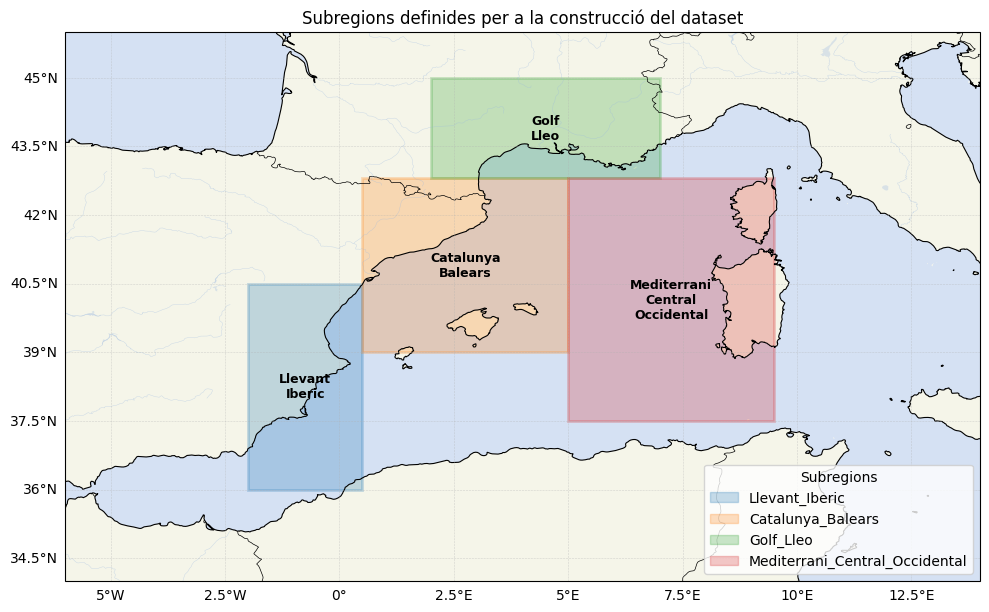

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extensió del mapa: oest, est, sud, nord
ax.set_extent([-6, 14, 34, 46], crs=ccrs.PlateCarree())

# Fons del mapa
ax.add_feature(cfeature.OCEAN, alpha=0.4)
ax.add_feature(cfeature.LAND, alpha=0.6)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.3)
ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.5)

# Graella de coordenades
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    alpha=0.5
)
gl.top_labels = False
gl.right_labels = False

# Colors per subregió
colors = {
    "Llevant_Iberic": "tab:blue",
    "Catalunya_Balears": "tab:orange",
    "Golf_Lleo": "tab:green",
    "Mediterrani_Central_Occidental": "tab:red",
}

legend_handles = []

# Dibuixar rectangles de les subregions
for nom, r in regions.items():
    color = colors.get(nom, "black")

    rect = Rectangle(
        (r["lon_min"], r["lat_min"]),
        r["lon_max"] - r["lon_min"],
        r["lat_max"] - r["lat_min"],
        linewidth=2,
        edgecolor=color,
        facecolor=color,
        alpha=0.25,
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)

    lon_c = (r["lon_min"] + r["lon_max"]) / 2
    lat_c = (r["lat_min"] + r["lat_max"]) / 2

    ax.text(
        lon_c,
        lat_c,
        nom.replace("_", "\n"),
        ha="center",
        va="center",
        fontsize=9,
        weight="bold",
        transform=ccrs.PlateCarree()
    )

    legend_handles.append(
        Patch(facecolor=color, edgecolor=color, alpha=0.25, label=nom)
    )

ax.set_title("Subregions definides per a la construcció del dataset")
ax.legend(handles=legend_handles, title="Subregions", loc="lower right")

plt.tight_layout()
plt.savefig(FIG / "01_mapa_subregions.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
def region_mean(ds: xr.Dataset, var_name: str, lat_min: float, lat_max: float, lon_min: float, lon_max: float):
    """
    Calcula la mitjana espacial d'una variable dins d'una caixa lat/lon.
    Les latituds d'ERA5 solen estar en ordre descendent, per això usem slice(lat_max, lat_min).
    """
    subset = ds[var_name].sel(
        latitude=slice(lat_max, lat_min),
        longitude=slice(lon_min, lon_max)
    )

    return subset.mean(dim=["latitude", "longitude"], skipna=True)

In [11]:
climate_rows = []

for region_name, bounds in regions.items():
    region_bounds = {k: v for k, v in bounds.items() if k.startswith("lat_") or k.startswith("lon_")}

    row = pd.DataFrame({
        "data": pd.to_datetime(era5.time.values),
        "subregio": region_name,
    })

    row["temperatura_mitjana"] = region_mean(era5, "t2m_c", **region_bounds).values
    row["precipitacio_mm_dia"] = region_mean(era5, "tp_mm_dia", **region_bounds).values
    row["pressio_nivell_mar"] = region_mean(era5, "msl_hpa", **region_bounds).values
    row["vent_u10"] = region_mean(era5, "u10", **region_bounds).values
    row["vent_v10"] = region_mean(era5, "v10", **region_bounds).values
    row["temperatura_superficie_mar"] = region_mean(era5, "sst_c", **region_bounds).values

    climate_rows.append(row)

climate_df = pd.concat(climate_rows, ignore_index=True)

climate_df["any"] = climate_df["data"].dt.year
climate_df["mes"] = climate_df["data"].dt.month
climate_df["dies_mes"] = climate_df["data"].dt.days_in_month
climate_df["precipitacio_mensual_mm"] = climate_df["precipitacio_mm_dia"] * climate_df["dies_mes"]

print(climate_df.shape)
climate_df.head()

(1920, 12)


,data,subregio,temperatura_mitjana,precipitacio_mm_dia,pressio_nivell_mar,vent_u10,vent_v10,temperatura_superficie_mar,any,mes,dies_mes,precipitacio_mensual_mm
0,1981-01-01,Llevant_Iberic,9.200457,0.514008,1025.401001,1.407515,-0.972726,14.095931,1981,1,31,15.934236
1,1981-02-01,Llevant_Iberic,9.363039,1.193188,1019.806091,0.389739,-0.972727,13.644383,1981,2,28,33.409266
2,1981-03-01,Llevant_Iberic,13.703812,0.397577,1015.606445,1.784614,0.515340,14.553995,1981,3,31,12.324894
3,1981-04-01,Llevant_Iberic,13.411357,3.294639,1014.092285,0.120877,-0.263017,15.798634,1981,4,30,98.839173
4,1981-05-01,Llevant_Iberic,16.145916,0.834579,1014.405029,1.138123,0.265960,16.973034,1981,5,31,25.871952


In [12]:
land_rows = []

for region_name, bounds in regions.items():
    region_bounds = {k: v for k, v in bounds.items() if k.startswith("lat_") or k.startswith("lon_")}

    row = pd.DataFrame({
        "data": pd.to_datetime(land.time.values),
        "subregio": region_name,
    })

    row["humitat_sol_capa1"] = region_mean(land, "swvl1", **region_bounds).values
    row["humitat_sol_capa2"] = region_mean(land, "swvl2", **region_bounds).values
    row["evaporacio_potencial"] = region_mean(land, "pev", **region_bounds).values

    land_rows.append(row)

land_df = pd.concat(land_rows, ignore_index=True)

land_df["any"] = land_df["data"].dt.year
land_df["mes"] = land_df["data"].dt.month

print(land_df.shape)
land_df.head()

(1920, 7)


,data,subregio,humitat_sol_capa1,humitat_sol_capa2,evaporacio_potencial,any,mes
0,1981-01-01,Llevant_Iberic,0.202509,0.218774,-0.002775,1981,1
1,1981-02-01,Llevant_Iberic,0.223601,0.218593,-0.003215,1981,2
2,1981-03-01,Llevant_Iberic,0.180810,0.205097,-0.005482,1981,3
3,1981-04-01,Llevant_Iberic,0.300911,0.274394,-0.004634,1981,4
4,1981-05-01,Llevant_Iberic,0.244571,0.269297,-0.007356,1981,5


In [13]:
season_to_month = {
    "DJF": 1,
    "JFM": 2,
    "FMA": 3,
    "MAM": 4,
    "AMJ": 5,
    "MJJ": 6,
    "JJA": 7,
    "JAS": 8,
    "ASO": 9,
    "SON": 10,
    "OND": 11,
    "NDJ": 12,
}


def enso_wide_to_long(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    """
    Converteix una taula anual ampla d'ONI/RONI a format mensual llarg.
    """
    df_long = df.melt(
        id_vars="Year",
        var_name="estacio_3m",
        value_name=value_name
    )

    df_long["mes"] = df_long["estacio_3m"].map(season_to_month)
    df_long = df_long.rename(columns={"Year": "any"})

    df_long["data"] = pd.to_datetime(
        dict(year=df_long["any"], month=df_long["mes"], day=1),
        errors="coerce"
    )

    df_long = df_long.sort_values("data").reset_index(drop=True)
    return df_long


oni_raw = pd.read_csv(ONI_PATH)
roni_raw = pd.read_csv(RONI_PATH)

oni_long = enso_wide_to_long(oni_raw, "oni")
roni_long = enso_wide_to_long(roni_raw, "roni")

enso = oni_long.merge(
    roni_long[["data", "roni"]],
    on="data",
    how="outer"
).sort_values("data").reset_index(drop=True)

enso = enso[(enso["data"] >= DATA_INICI) & (enso["data"] <= DATA_FINAL)].copy()

def classificar_enso(x):
    if pd.isna(x):
        return np.nan
    if x >= 0.5:
        return "El Nino"
    elif x <= -0.5:
        return "La Nina"
    else:
        return "Neutral"

enso["fase_enso"] = enso["roni"].apply(classificar_enso)

# Retards temporals per si més endavant vols estudiar efectes diferits.
for lag in [1, 3, 6]:
    enso[f"oni_lag_{lag}"] = enso["oni"].shift(lag)
    enso[f"roni_lag_{lag}"] = enso["roni"].shift(lag)

print(enso.shape)
enso.head()

(480, 13)


,any,estacio_3m,oni,mes,data,roni,fase_enso,oni_lag_1,roni_lag_1,oni_lag_3,roni_lag_3,oni_lag_6,roni_lag_6
372,1981,DJF,-0.3,1,1981-01-01,0.0,Neutral,NaN,NaN,NaN,NaN,NaN,NaN
373,1981,JFM,-0.5,2,1981-02-01,-0.3,Neutral,-0.3,0.0,NaN,NaN,NaN,NaN
374,1981,FMA,-0.5,3,1981-03-01,-0.3,Neutral,-0.5,-0.3,NaN,NaN,NaN,NaN
375,1981,MAM,-0.4,4,1981-04-01,-0.3,Neutral,-0.5,-0.3,-0.3,0.0,NaN,NaN
376,1981,AMJ,-0.3,5,1981-05-01,-0.3,Neutral,-0.4,-0.3,-0.5,-0.3,NaN,NaN


In [14]:
nao = pd.read_csv(NAO_PATH)
nao.columns = ["data", "nao"]

nao["data"] = pd.to_datetime(nao["data"], errors="coerce")
nao["nao"] = pd.to_numeric(nao["nao"], errors="coerce")

# Valors absents codificats
nao["nao"] = nao["nao"].replace([-9999, -9999.0, -99.99], np.nan)

nao = nao[(nao["data"] >= DATA_INICI) & (nao["data"] <= DATA_FINAL)].copy()
nao["any"] = nao["data"].dt.year
nao["mes"] = nao["data"].dt.month

print(nao.shape)
nao.head()

(480, 4)


,data,nao,any,mes
1920,1981-01-01,1.00,1981,1
1921,1981-02-01,1.04,1981,2
1922,1981-03-01,0.01,1981,3
1923,1981-04-01,-3.04,1981,4
1924,1981-05-01,0.05,1981,5


In [15]:
wemo = pd.read_csv(
    WEMO_PATH,
    sep=r"\s+|\t+",
    engine="python",
    skiprows=7
).reset_index()

wemo.columns = ["any", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Convertim comes decimals a punts i valors absents a NaN.
for col in wemo.columns[1:]:
    wemo[col] = (
        wemo[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace(["-999", "-999.0"], np.nan)
    )
    wemo[col] = pd.to_numeric(wemo[col], errors="coerce")

month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

wemo_long = wemo.melt(
    id_vars="any",
    var_name="mes_nom",
    value_name="wemo"
)

wemo_long["mes"] = wemo_long["mes_nom"].map(month_map)
wemo_long["data"] = pd.to_datetime(
    dict(year=wemo_long["any"], month=wemo_long["mes"], day=1),
    errors="coerce"
)

wemo_long = (
    wemo_long
    .drop(columns=["mes_nom"])
    .sort_values("data")
    .reset_index(drop=True)
)

wemo_long = wemo_long[
    (wemo_long["data"] >= DATA_INICI) &
    (wemo_long["data"] <= DATA_FINAL)
].copy()

print(wemo_long.shape)
wemo_long.head()

(480, 4)


,any,wemo,mes,data
1920,1981,1.27,1,1981-01-01
1921,1981,-0.18,2,1981-02-01
1922,1981,0.48,3,1981-03-01
1923,1981,-1.36,4,1981-04-01
1924,1981,1.69,5,1981-05-01


In [16]:
def classificar_fase_index(x):
    if pd.isna(x):
        return np.nan
    if x >= 0.5:
        return "Positive"
    elif x <= -0.5:
        return "Negative"
    else:
        return "Neutral"


tele = enso.merge(
    nao[["data", "nao"]],
    on="data",
    how="left"
)

tele = tele.merge(
    wemo_long[["data", "wemo"]],
    on="data",
    how="left"
)

tele["any"] = tele["data"].dt.year
tele["mes"] = tele["data"].dt.month

def mes_a_estacio(mes):
    if mes in [12, 1, 2]:
        return "Winter"
    elif mes in [3, 4, 5]:
        return "Spring"
    elif mes in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


def any_a_periode(any):
    if 1981 <= any <= 1990:
        return "1981-1990"
    elif 1991 <= any <= 2000:
        return "1991-2000"
    elif 2001 <= any <= 2010:
        return "2001-2010"
    elif 2011 <= any <= 2020:
        return "2011-2020"
    else:
        return np.nan


tele["estacio"] = tele["mes"].apply(mes_a_estacio)
tele["periode"] = tele["any"].apply(any_a_periode)
tele["fase_nao"] = tele["nao"].apply(classificar_fase_index)
tele["fase_wemo"] = tele["wemo"].apply(classificar_fase_index)

tele.to_csv(OUT_TELE, index=False)

print("Guardat:", OUT_TELE)
print(tele.shape)
tele.head()

Guardat: ../data_processed/teleconnections_monthly_1981_2020_v2.csv
(480, 19)


,any,estacio_3m,oni,mes,data,roni,fase_enso,oni_lag_1,roni_lag_1,oni_lag_3,roni_lag_3,oni_lag_6,roni_lag_6,nao,wemo,estacio,periode,fase_nao,fase_wemo
0,1981,DJF,-0.3,1,1981-01-01,0.0,Neutral,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.27,Winter,1981-1990,Positive,Positive
1,1981,JFM,-0.5,2,1981-02-01,-0.3,Neutral,-0.3,0.0,NaN,NaN,NaN,NaN,1.04,-0.18,Winter,1981-1990,Positive,Neutral
2,1981,FMA,-0.5,3,1981-03-01,-0.3,Neutral,-0.5,-0.3,NaN,NaN,NaN,NaN,0.01,0.48,Spring,1981-1990,Neutral,Neutral
3,1981,MAM,-0.4,4,1981-04-01,-0.3,Neutral,-0.5,-0.3,-0.3,0.0,NaN,NaN,-3.04,-1.36,Spring,1981-1990,Negative,Negative
4,1981,AMJ,-0.3,5,1981-05-01,-0.3,Neutral,-0.4,-0.3,-0.5,-0.3,NaN,NaN,0.05,1.69,Spring,1981-1990,Neutral,Positive


In [17]:
df = climate_df.merge(
    land_df,
    on=["data", "subregio", "any", "mes"],
    how="left"
)

df = df.merge(
    tele,
    on=["data", "any", "mes"],
    how="left"
)

print(df.shape)
df.head()

(1920, 31)


,data,subregio,temperatura_mitjana,precipitacio_mm_dia,pressio_nivell_mar,vent_u10,vent_v10,temperatura_superficie_mar,any,mes,...,oni_lag_3,roni_lag_3,oni_lag_6,roni_lag_6,nao,wemo,estacio,periode,fase_nao,fase_wemo
0,1981-01-01,Llevant_Iberic,9.200457,0.514008,1025.401001,1.407515,-0.972726,14.095931,1981,1,...,NaN,NaN,NaN,NaN,1.00,1.27,Winter,1981-1990,Positive,Positive
1,1981-02-01,Llevant_Iberic,9.363039,1.193188,1019.806091,0.389739,-0.972727,13.644383,1981,2,...,NaN,NaN,NaN,NaN,1.04,-0.18,Winter,1981-1990,Positive,Neutral
2,1981-03-01,Llevant_Iberic,13.703812,0.397577,1015.606445,1.784614,0.515340,14.553995,1981,3,...,NaN,NaN,NaN,NaN,0.01,0.48,Spring,1981-1990,Neutral,Neutral
3,1981-04-01,Llevant_Iberic,13.411357,3.294639,1014.092285,0.120877,-0.263017,15.798634,1981,4,...,-0.3,0.0,NaN,NaN,-3.04,-1.36,Spring,1981-1990,Negative,Negative
4,1981-05-01,Llevant_Iberic,16.145916,0.834579,1014.405029,1.138123,0.265960,16.973034,1981,5,...,-0.5,-0.3,NaN,NaN,0.05,1.69,Spring,1981-1990,Neutral,Positive


In [18]:
# Climatologia mensual per subregió.
# És a dir, per cada subregió i mes de l'any calculem el valor mitjà del període 1981-2020.

clim_vars = {
    "temperatura_mitjana": "climatologia_temperatura",
    "precipitacio_mm_dia": "climatologia_precipitacio_mm_dia",
    "precipitacio_mensual_mm": "climatologia_precipitacio_mensual_mm",
    "temperatura_superficie_mar": "climatologia_sst",
    "humitat_sol_capa1": "climatologia_humitat_sol_capa1",
}

for var, clim_name in clim_vars.items():
    df[clim_name] = df.groupby(["subregio", "mes"])[var].transform("mean")

df["anomalia_temperatura"] = df["temperatura_mitjana"] - df["climatologia_temperatura"]
df["anomalia_precipitacio_mm_dia"] = df["precipitacio_mm_dia"] - df["climatologia_precipitacio_mm_dia"]
df["anomalia_precipitacio_mensual_mm"] = df["precipitacio_mensual_mm"] - df["climatologia_precipitacio_mensual_mm"]
df["anomalia_sst"] = df["temperatura_superficie_mar"] - df["climatologia_sst"]
df["anomalia_humitat_sol_capa1"] = df["humitat_sol_capa1"] - df["climatologia_humitat_sol_capa1"]

# Variables derivades addicionals
df["velocitat_vent"] = np.sqrt(df["vent_u10"]**2 + df["vent_v10"]**2)

df["nao_abs"] = df["nao"].abs()
df["wemo_abs"] = df["wemo"].abs()
df["roni_abs"] = df["roni"].abs()

# Llindars simples per a narrativa visual.
df["mes_molt_calid"] = df["anomalia_temperatura"] > 1
df["mes_molt_fred"] = df["anomalia_temperatura"] < -1
df["mes_molt_sec"] = df["anomalia_precipitacio_mensual_mm"] < -30
df["mes_molt_humit"] = df["anomalia_precipitacio_mensual_mm"] > 30

df["sol_molt_sec"] = df["anomalia_humitat_sol_capa1"] < -0.02
df["sol_molt_humit"] = df["anomalia_humitat_sol_capa1"] > 0.02

df["episodi_calid_i_sec"] = df["mes_molt_calid"] & df["mes_molt_sec"]
df["episodi_fred_i_humit"] = df["mes_molt_fred"] & df["mes_molt_humit"]
df["episodi_calid_i_sol_sec"] = df["mes_molt_calid"] & df["sol_molt_sec"]

df.head()

,data,subregio,temperatura_mitjana,precipitacio_mm_dia,pressio_nivell_mar,vent_u10,vent_v10,temperatura_superficie_mar,any,mes,...,roni_abs,mes_molt_calid,mes_molt_fred,mes_molt_sec,mes_molt_humit,sol_molt_sec,sol_molt_humit,episodi_calid_i_sec,episodi_fred_i_humit,episodi_calid_i_sol_sec
0,1981-01-01,Llevant_Iberic,9.200457,0.514008,1025.401001,1.407515,-0.972726,14.095931,1981,1,...,0.0,False,True,False,False,True,False,False,False,False
1,1981-02-01,Llevant_Iberic,9.363039,1.193188,1019.806091,0.389739,-0.972727,13.644383,1981,2,...,0.3,False,True,False,False,True,False,False,False,False
2,1981-03-01,Llevant_Iberic,13.703812,0.397577,1015.606445,1.784614,0.515340,14.553995,1981,3,...,0.3,True,False,False,False,True,False,False,False,True
3,1981-04-01,Llevant_Iberic,13.411357,3.294639,1014.092285,0.120877,-0.263017,15.798634,1981,4,...,0.3,False,False,False,True,False,True,False,False,False
4,1981-05-01,Llevant_Iberic,16.145916,0.834579,1014.405029,1.138123,0.265960,16.973034,1981,5,...,0.3,False,True,False,False,False,True,False,False,False


In [19]:
ordre_estacions = ["Winter", "Spring", "Summer", "Autumn"]
ordre_periodes = ["1981-1990", "1991-2000", "2001-2010", "2011-2020"]
ordre_fases = ["Negative", "Neutral", "Positive"]
ordre_enso = ["La Nina", "Neutral", "El Nino"]

df["estacio"] = pd.Categorical(df["estacio"], categories=ordre_estacions, ordered=True)
df["periode"] = pd.Categorical(df["periode"], categories=ordre_periodes, ordered=True)
df["fase_nao"] = pd.Categorical(df["fase_nao"], categories=ordre_fases, ordered=True)
df["fase_wemo"] = pd.Categorical(df["fase_wemo"], categories=ordre_fases, ordered=True)
df["fase_enso"] = pd.Categorical(df["fase_enso"], categories=ordre_enso, ordered=True)

print("Dimensions:", df.shape)
print("Duplicats data-subregio:", df.duplicated(subset=["data", "subregio"]).sum())
print("Percentatge de nuls màxim:", (df.isna().mean() * 100).max())

display(df.isna().mean().sort_values(ascending=False).head(10))
display(df["subregio"].value_counts())

Dimensions: (1920, 54)
Duplicats data-subregio: 0
Percentatge de nuls màxim: 1.25


roni_lag_6             0.012500
oni_lag_6              0.012500
oni_lag_3              0.006250
roni_lag_3             0.006250
roni_lag_1             0.002083
oni_lag_1              0.002083
vent_u10               0.000000
pressio_nivell_mar     0.000000
precipitacio_mm_dia    0.000000
vent_v10               0.000000
dtype: float64

subregio
Llevant_Iberic                    480
Catalunya_Balears                 480
Golf_Lleo                         480
Mediterrani_Central_Occidental    480
Name: count, dtype: int64

In [20]:
# Dataset complet
df.to_csv(OUT_FULL, index=False)

# Dataset reduït per a visualització final
cols_main = [
    "data", "any", "mes", "dies_mes", "estacio", "periode", "subregio",
    "nao", "wemo", "roni", "fase_nao", "fase_wemo", "fase_enso",

    "temperatura_mitjana",
    "precipitacio_mm_dia",
    "precipitacio_mensual_mm",
    "humitat_sol_capa1",
    "humitat_sol_capa2",
    "evaporacio_potencial",
    "temperatura_superficie_mar",
    "pressio_nivell_mar",
    "vent_u10",
    "vent_v10",
    "velocitat_vent",

    "anomalia_temperatura",
    "anomalia_precipitacio_mm_dia",
    "anomalia_precipitacio_mensual_mm",
    "anomalia_humitat_sol_capa1",
    "anomalia_sst",

    "mes_molt_calid",
    "mes_molt_fred",
    "mes_molt_sec",
    "mes_molt_humit",
    "sol_molt_sec",
    "sol_molt_humit",
    "episodi_calid_i_sec",
    "episodi_fred_i_humit",
    "episodi_calid_i_sol_sec",
]

df_main = df[cols_main].copy()
df_main.to_csv(OUT_MAIN, index=False)

print("Dataset complet guardat a:", OUT_FULL)
print("Dataset principal guardat a:", OUT_MAIN)
print("Shape complet:", df.shape)
print("Shape principal:", df_main.shape)

df_main.head()

Dataset complet guardat a: ../data_processed/teleconnections_catalonia_1981_2020_v2.csv
Dataset principal guardat a: ../data_processed/teleconnections_catalonia_1981_2020_main_v2.csv
Shape complet: (1920, 54)
Shape principal: (1920, 38)


,data,any,mes,dies_mes,estacio,periode,subregio,nao,wemo,roni,...,anomalia_sst,mes_molt_calid,mes_molt_fred,mes_molt_sec,mes_molt_humit,sol_molt_sec,sol_molt_humit,episodi_calid_i_sec,episodi_fred_i_humit,episodi_calid_i_sol_sec
0,1981-01-01,1981,1,31,Winter,1981-1990,Llevant_Iberic,1.00,1.27,0.0,...,-0.891328,False,True,False,False,True,False,False,False,False
1,1981-02-01,1981,2,28,Winter,1981-1990,Llevant_Iberic,1.04,-0.18,-0.3,...,-0.814626,False,True,False,False,True,False,False,False,False
2,1981-03-01,1981,3,31,Spring,1981-1990,Llevant_Iberic,0.01,0.48,-0.3,...,-0.302593,True,False,False,False,True,False,False,False,True
3,1981-04-01,1981,4,30,Spring,1981-1990,Llevant_Iberic,-3.04,-1.36,-0.3,...,-0.168856,False,False,False,True,False,True,False,False,False
4,1981-05-01,1981,5,31,Spring,1981-1990,Llevant_Iberic,0.05,1.69,-0.3,...,-1.155891,False,True,False,False,False,True,False,False,False
